# Netflix Movies & TV Shows  

## EDA 초안 정리본

> **목표**  
> 이 데이터로 **어디까지 말할 수 있는지** 먼저 확인하고,  
> EDA 결과를 바탕으로 **최종 분석 범위와 모델링 후보를 좁히는 것**을 목표로 한다.

## 접근 방식

1. 이 데이터는 **인기/성과 분석**보다 **카탈로그 구조 분석**에 더 적합한가?  
2. 넷플릭스 카탈로그는 **어떤 유형·국가·등급 중심**으로 구성되어 있는가?  
3. 시간 흐름에 따라 **포트폴리오 변화**가 나타나는가?  
4. 위 결과를 바탕으로 **최종 분석 주제를 어디까지 좁히는 것이 타당한가?**

## 1. 분석 환경 세팅 & 데이터 호출

### 확인사항
- 분석 환경을 세팅하고, 데이터의 **행 수·열 수·기본 구조**를 먼저 확인한다.

### 목적
- 데이터의 기본 구조를 먼저 파악하여, 이후 분석을 어떤 방향으로 가져갈지 결정한다.

In [1]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 세팅값 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='Set2')

# 한글 깨짐 방지, 음수 기호 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [17]:
# 데이터 호출
df_raw = pd.read_csv('netflix_titles.csv')
print(f"데이터 크기: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열")
print('='*50)
display(df_raw.head())

데이터 크기: 8,807행 × 12열


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshab...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her si..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert ...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into ..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student a..."


### 해석
- 데이터 규모는 **8,807행 × 12열**로 구성
- 주요 컬럼은 `type`, `country`, `date_added`, `release_year`, `rating`, `listed_in`, `description` 등으로 확인된다.
- 즉, 이 데이터는 **사용자 행동 로그가 아니라 콘텐츠 메타데이터 중심 데이터**에 가깝다.
- 따라서 **인기 콘텐츠나 시청 성과 분석**보다는, **카탈로그 포트폴리오 구조를 파악하는 분석**에 더 적합하다고 판단된다.

## 2. 데이터 구조 및 품질 점검

### 확인사항
- 데이터의 전체 컬럼 구성을 확인한다.
    - 어떤 컬럼이 있는지
    - 각 컬럼의 데이터 타입은 무엇인지
    - 결측치는 어디에 얼마나 있는지
    - 완전 중복 행이 있는지
    - 바로 전처리가 필요한 핵심 컬럼이 무엇인지

### 목적
- 데이터로 **어디까지 분석할 수 있는지** 판단하기 위해, 먼저 **컬럼 구조와 품질 상태**를 점검한다.
- 특히 이 데이터는 콘텐츠 메타데이터 중심이므로, **수요 분석보다 공급 구조 분석이 더 적합한지** 확인할 필요가 있다.

In [14]:
print("컬럼 목록")
print('='*50)
print(df_raw.columns.tolist())
print()

print("데이터 타입 및 결측 정보")
print('='*50)
df_raw.info()
print()

컬럼 목록
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

데이터 타입 및 결측 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB



### 컬럼명 해석
- `show_id` : 콘텐츠 고유 ID  
  - 각 작품을 구분하는 식별자 (예: s1, s2 ...)
- `type` : 콘텐츠 유형  
  - Movie 또는 TV Show 여부
- `title` : 제목  
  - 작품명
- `director` : 감독  
  - 작품을 연출한 감독 정보
- `cast` : 출연진  
  - 주요 출연 배우 목록
- `country` : 제작 국가  
  - 작품의 주요 제작 국가
- `date_added` : 넷플릭스 등록일  
  - 작품이 넷플릭스에 추가된 날짜
- `release_year` : 개봉/방영 연도  
  - 작품이 처음 공개된 연도
- `rating` : 관람 등급  
  - 시청 연령 등급 (예: TV-MA, PG-13 등)
- `duration` : 분량  
  - Movie는 상영 시간, TV Show는 시즌 수
- `listed_in` : 장르 / 카테고리  
  - 작품이 속한 장르 정보
- `description` : 줄거리 요약  
  - 작품의 간단한 소개 문장

In [16]:
missing_count = df_raw.isna().sum().sort_values(ascending=False)
missing_ratio = (df_raw.isna().mean() * 100).sort_values(ascending=False).round(2)

print(f"중복 행 수: {df_raw.duplicated().sum()}개")
print('='*50)
print("\n컬럼별 결측치 개수")
print('='*50)
print(missing_count)
print("\n컬럼별 결측치 비율(%)")
print('='*50)
print(missing_ratio)

중복 행 수: 0개

컬럼별 결측치 개수
director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

컬럼별 결측치 비율(%)
director        29.91
country          9.44
cast             9.37
date_added       0.11
rating           0.05
duration         0.03
show_id          0.00
type             0.00
title            0.00
release_year     0.00
listed_in        0.00
description      0.00
dtype: float64


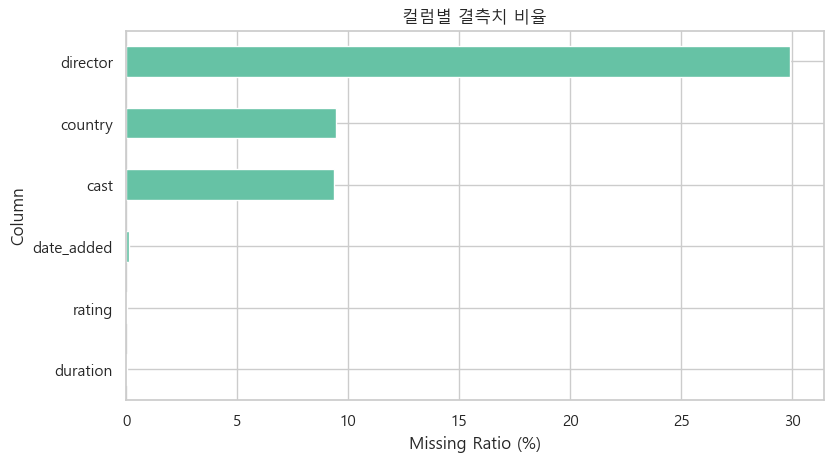

In [4]:
plt.figure(figsize=(9, 4.8))
missing_ratio[missing_ratio > 0].sort_values().plot(kind="barh")
plt.title("컬럼별 결측치 비율")
plt.xlabel("Missing Ratio (%)")
plt.ylabel("Column")
plt.show()

### 해석
- 완전 중복 행은 0개로 확인되어, **중복 자체는 주요 이슈가 아니었다.**
- 결측은 `director(29.91%)`, `country(9.44%)`, `cast(9.37%)`에 상대적으로 많이 분포했다.
- 다만 이 컬럼들은 분석 가치가 남아 있으므로, **행 삭제보다는 대체값을 부여해 보존하는 방향**이 더 적절하다고 판단된다.

### 해석
- 반면 `date_added`, `rating`, `duration`의 결측은 매우 적은 수준이었다.
- 따라서 **연도·등급 기반 분석은 큰 표본 손실 없이 진행 가능**하다고 판단했다.
- 다만 `date_added`는 시간축 분석에 직접 사용되는 컬럼이므로, 결측 행은 관련 EDA에서만 제외하는 규칙이 필요하다.
- 이를 바탕으로, 이번 탐색에서는 감독·출연진보다 **유형(`type`)·국가(`country`)·등급(`rating`)·시점(`date_added`)**을 우선적으로 보는 것이 적절하다고 정리했다.

## 3. 전처리: 분석 가능한 형태로 최소 정리

### 목적
- 결측 처리 기준을 먼저 정리해, 이후 시각화와 해석의 신뢰도를 높인다.
- 특히 `country`, `director`, `cast`, `date_added`, `rating`은 이후 분석에 직접 영향을 주는 핵심 컬럼이므로, 처리 기준을 명확히 둘 필요가 있다.

### 전처리 원칙
- **행 삭제 최소화**: 표본 손실보다 해석 가능한 구조 확보가 더 중요
- `director`, `cast`, `country`, `rating`, `duration`은 결측값을 `Unknown`으로 보존
- `date_added`는 날짜 분석에 중요한 컬럼이기에 문자열을 날짜형으로 바꾸고, 연도/월 파생 컬럼 생성
- `country`, `listed_in`은 다중값 컬럼으로, **대표값 기준**으로 단순화(`primary_country`, `primary_genre`)
- `rating` 컬럼에 duration 값이 잘못 들어간 사례가 있는지 점검 (예: min)
- - `rating`은 원본 분포를 유지하되, 필요 시 그룹화할 수 있도록 함께 정리

In [22]:
df = df_raw.copy()

# 1) 완전 중복 제거
df = df.drop_duplicates().copy()

# 2) 날짜형 변환
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# 3) rating 이상치 점검 및 보정 (duration 값이 rating에 들어간 경우)
weird_rating_mask = df['rating'].astype(str).str.contains('min', na=False)
df.loc[weird_rating_mask, 'duration'] = df.loc[weird_rating_mask, 'rating']
df.loc[weird_rating_mask, 'rating'] = np.nan

# 4) 결측 처리
for col in ["director", "cast", "country", "rating", "duration"]:
    df[col] = df[col].fillna("Unknown")

# 5) 다중값 컬럼 단순화
df["primary_country"] = df["country"].astype(str).str.split(",").str[0].str.strip()
df["primary_genre"] = df["listed_in"].astype(str).str.split(",").str[0].str.strip()

# 6) rating 그룹화
kids = ["TV-Y", "TV-Y7", "TV-G", "G"]
teens = ["PG", "PG-13", "TV-PG", "TV-14"]
adults = ["R", "NC-17", "TV-MA"]
unknown = ["NR", "UR", "Unknown"]

def map_rating_group(x):
    if x in kids:
        return "Kids"
    elif x in teens:
        return "Teens"
    elif x in adults:
        return "Adults"
    elif x in unknown:
        return "Not Rated / Unknown"
    else:
        return "Other"

df["rating_group"] = df["rating"].apply(map_rating_group)

# 7) 작품 공개 후 Netflix 편입 시차
df["content_age_when_added"] = df["year_added"] - df["release_year"]

print(f"rating 컬럼 이상치(분 단위 문자열) 개수: {weird_rating_mask.sum()}개")
display(df[["title", "type", "primary_country", "primary_genre", "rating", "rating_group", "release_year", "year_added", "content_age_when_added"]].head(5))

rating 컬럼 이상치(분 단위 문자열) 개수: 3개


,title,type,primary_country,primary_genre,rating,rating_group,release_year,year_added,content_age_when_added
0,Dick Johnson Is Dead,Movie,United States,Documentaries,PG-13,Teens,2020,2021.0,1.0
1,Blood & Water,TV Show,South Africa,International TV Shows,TV-MA,Adults,2021,2021.0,0.0
2,Ganglands,TV Show,Unknown,Crime TV Shows,TV-MA,Adults,2021,2021.0,0.0
3,Jailbirds New Orleans,TV Show,Unknown,Docuseries,TV-MA,Adults,2021,2021.0,0.0
4,Kota Factory,TV Show,India,International TV Shows,TV-MA,Adults,2021,2021.0,0.0


In [18]:
post_missing = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
print("전처리 후 결측 비율(상위 10개)")
print('='*50)
print(post_missing.head(10))

전처리 후 결측 비율(상위 10개)
content_age_when_added    1.11
date_added                1.11
year_added                1.11
month_added               1.11
type                      0.00
show_id                   0.00
country                   0.00
title                     0.00
cast                      0.00
director                  0.00
dtype: float64


### 해석
- 이번 전처리의 목적은 **결측을 무리하게 제거하는 것**보다, **분석 가능한 형태로 최소 정리하는 것**에 있다.
- `rating` 컬럼에서는 **duration 값이 잘못 들어간 행 3개**가 확인되어, 원래 위치로 되돌려 보정했다.
- `director`, `cast`, `country`, `rating`, `duration`은 `Unknown`으로 대체해, **표본 손실 없이 EDA를 이어갈 수 있도록** 정리했다.
- 다만 `primary_country`, `primary_genre`는 대표값만 남긴 변수이므로, 빠른 탐색에는 유리하지만 **다중 국가·다중 장르 정보 일부를 잃는 한계**가 있다.
- `date_added`에 날짜 정보가 없는 일부 행 때문에 `year_added`, `content_age_when_added`에는 약 **1.11% 결측**이 남았으며, 해당 변수 사용 시에만 제외하기로 했다.

### 해석 보완
- `Unknown` 대체는 표본을 유지하는 데에는 유리하지만, 해석 시 **실제 값이 비어 있는 경우**와 **확인할 수 없는 경우**를 함께 묶는 한계가 있다.
- 또한 `primary_country`, `primary_genre`는 빠른 EDA를 위한 대표값 중심 변수이므로, 이후 더 정교한 분석이 필요하면 `explode` 방식으로 확장할 수 있다.

## 4. 가설 1 — 넷플릭스는 어떤 카탈로그 구조를 가지고 있는가?

### 확인사항
- Movie와 TV Show 중 어떤 유형이 더 많은가
- 어떤 국가의 콘텐츠 비중이 큰가
- 어떤 장르와 등급 그룹이 큰 비중을 차지하는가

### 목적
- 기본 분포를 먼저 확인해, 이후 분석을 **유형 중심 / 국가 중심 / 등급 중심** 중 어디에 더 무게를 둘지 결정한다.

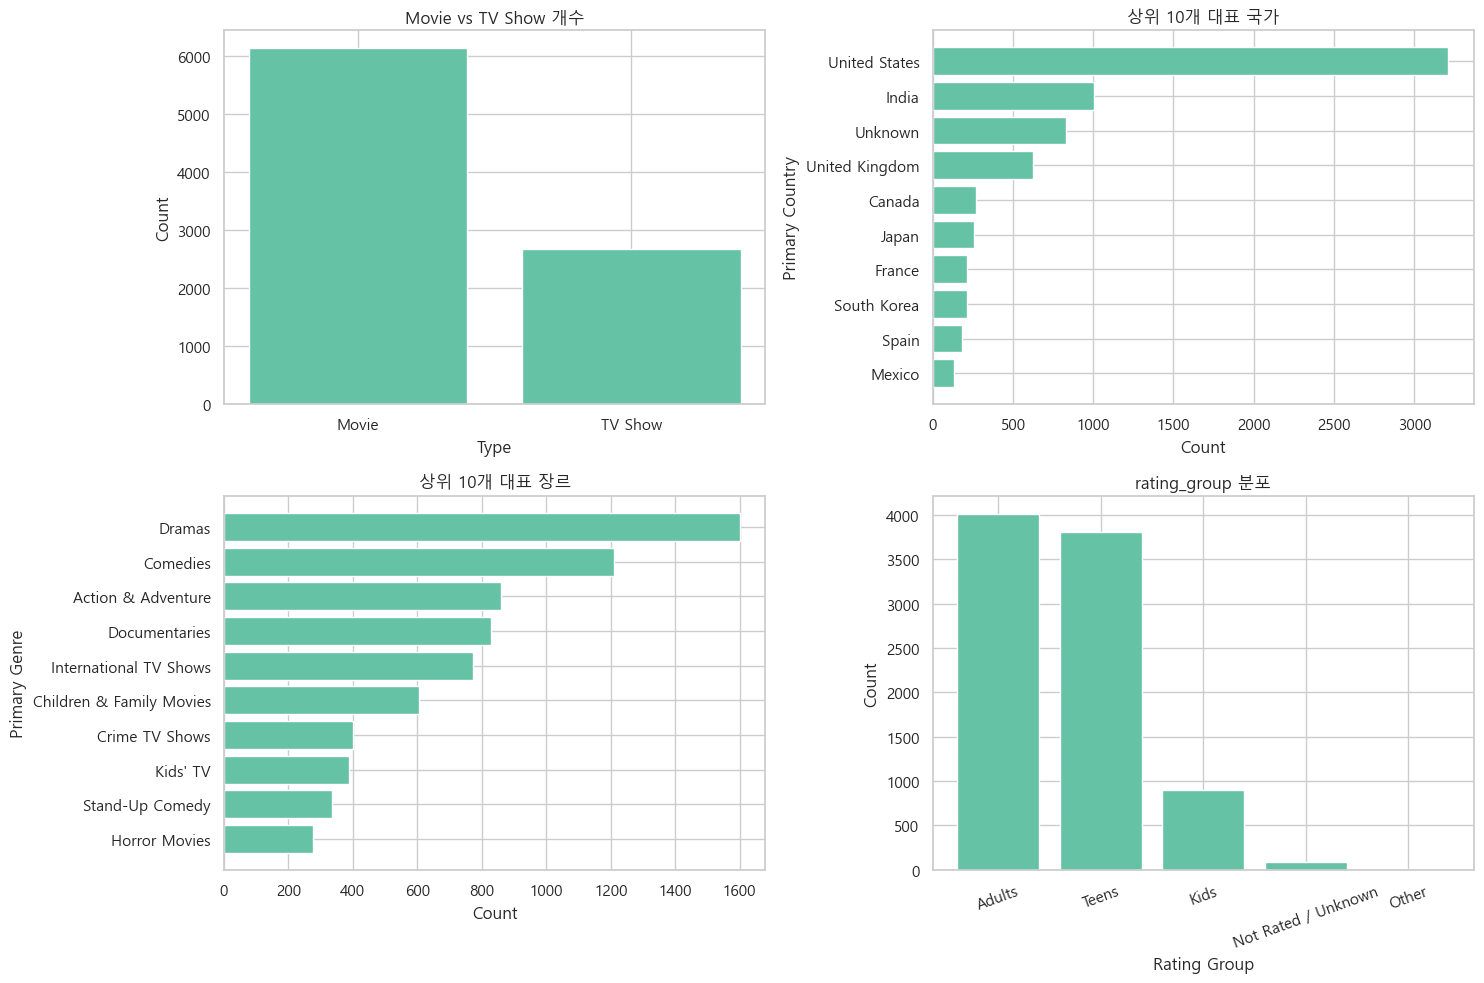

type 비율(%)
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) type 분포
type_counts = df["type"].value_counts()
axes[0, 0].bar(type_counts.index, type_counts.values)
axes[0, 0].set_title("Movie vs TV Show 개수")
axes[0, 0].set_xlabel("Type")
axes[0, 0].set_ylabel("Count")

# 2) 상위 국가
country_counts = df["primary_country"].value_counts().head(10)
axes[0, 1].barh(country_counts.index[::-1], country_counts.values[::-1])
axes[0, 1].set_title("상위 10개 대표 국가")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("Primary Country")

# 3) 상위 장르
genre_counts = df["primary_genre"].value_counts().head(10)
axes[1, 0].barh(genre_counts.index[::-1], genre_counts.values[::-1])
axes[1, 0].set_title("상위 10개 대표 장르")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("Primary Genre")

# 4) 등급 그룹
rating_group_counts = df["rating_group"].value_counts()
axes[1, 1].bar(rating_group_counts.index, rating_group_counts.values)
axes[1, 1].set_title("rating_group 분포")
axes[1, 1].set_xlabel("Rating Group")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("type 비율(%)")
print((df["type"].value_counts(normalize=True) * 100).round(2))

### 해석
- 전체 카탈로그는 **Movie 비중이 TV Show보다 훨씬 높아**, 넷플릭스가 여전히 **Movie 중심 구조**를 가지고 있음을 확인했다.
- 국가별로는 **United States(3,211건)** 비중이 가장 크고, 그다음은 **India(1,008건)**로 나타났다.
- 대표 장르는 **Dramas(1,600건)**, **Comedies(1,210건)**, **Action & Adventure(859건)** 순으로 확인됐다.
- `rating_group`은 **Adults 45.52%, Teens 43.15%**가 대부분을 차지해, 세부 등급보다 **상위 등급 그룹 중심으로 접근하는 편이 더 현실적**이라고 판단된다.

## 5. 가설 2 — 시간 흐름에 따라 포트폴리오 전환이 있었는가?

### 확인사항
- 연도별 콘텐츠 유입량이 언제부터 커졌는가
- Movie 중심 구조가 유지되었는지, TV Show 비중이 커졌는지

### 목적
- 단순 총량 비교를 넘어서, **언제부터 무엇이 늘었는지**를 확인한다.
- 이를 통해 넷플릭스의 **포트폴리오 변화 시점**을 더 직접적으로 해석해 보고자 한다.

<Figure size 1200x600 with 0 Axes>

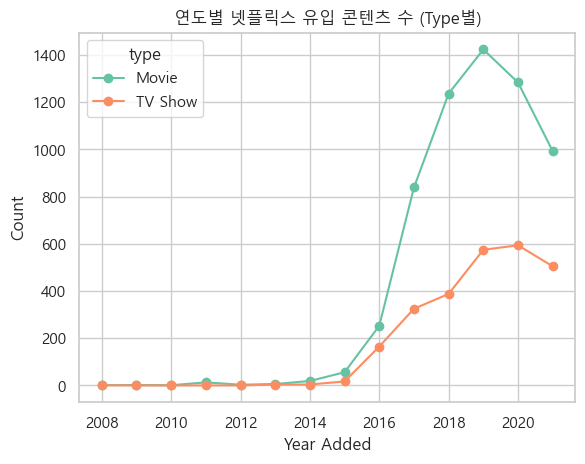

<Figure size 1200x600 with 0 Axes>

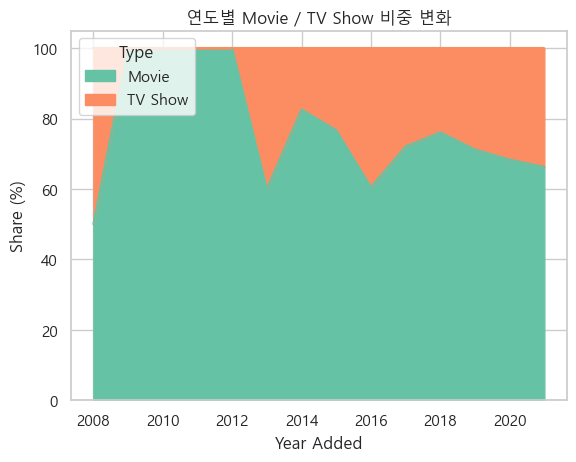

type,Movie,TV Show
year_added,,
2012.0,3,0
2013.0,6,4
2014.0,19,4
2015.0,56,17
2016.0,253,165
2017.0,839,325
2018.0,1237,388
2019.0,1424,575
2020.0,1284,594


In [23]:
year_type = (
    df.dropna(subset=['year_added'])
      .groupby(['year_added', 'type'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
year_type.plot(marker='o')
plt.title('연도별 넷플릭스 유입 콘텐츠 수 (Type별)')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.show()

year_type_ratio = year_type.div(year_type.sum(axis=1), axis=0) * 100
plt.figure(figsize=(12, 6))
year_type_ratio.plot(kind='area', stacked=True)
plt.title('연도별 Movie / TV Show 비중 변화')
plt.xlabel('Year Added')
plt.ylabel('Share (%)')
plt.legend(title='Type', loc='upper left')
plt.show()

display(year_type.tail(10))


### 해석
- 카탈로그 유입량은 **2016년부터 본격적으로 증가**했으며, **2019년**에 가장 높은 수준을 보였다.
- 2020~2021년에도 유입 규모는 여전히 크지만, 2019년 정점 이후에는 증가세가 다소 완만해졌다.
- Movie가 계속 더 많기는 하지만, TV Show도 함께 증가한 점을 보면 **단순한 영화 확장이라기보다 전체 카탈로그 확대 속에서 TV Show 비중도 함께 커진 구조**로 해석할 수 있다.
- 따라서 시간축에서는 **“언제 카탈로그가 급격히 확장되었는가”**, **“Movie 중심 구조 안에서 TV Show가 어떻게 커졌는가”**를 핵심 질문으로 두는 것이 적절하다.

## 6. 가설 3 — 주요 국가는 서로 다른 콘텐츠 포지션을 가지고 있는가?


### 확인사항
- 상위 국가들이 같은 방식으로 늘었는지
- 국가별로 Movie/TV Show 구성비가 다른지
- 국가별 대표 장르가 다른지

### 목적
- 단순 국가별 총량 비교를 넘어서, **어떤 국가가 언제부터 확대되었는지**를 확인한다.
- 이를 바탕으로 국가별 콘텐츠 전략을 더 입체적으로 해석해 보고자 한다.

<Figure size 1400x700 with 0 Axes>

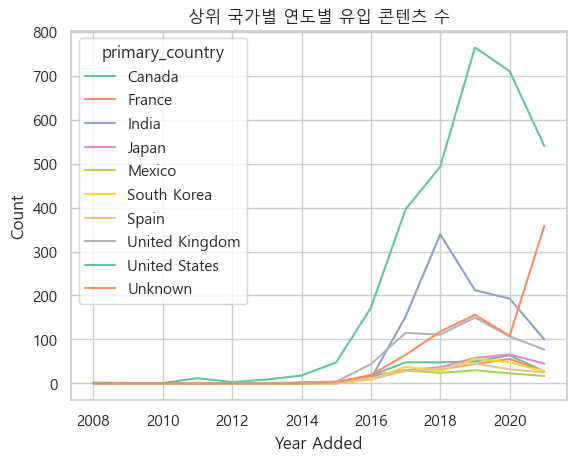

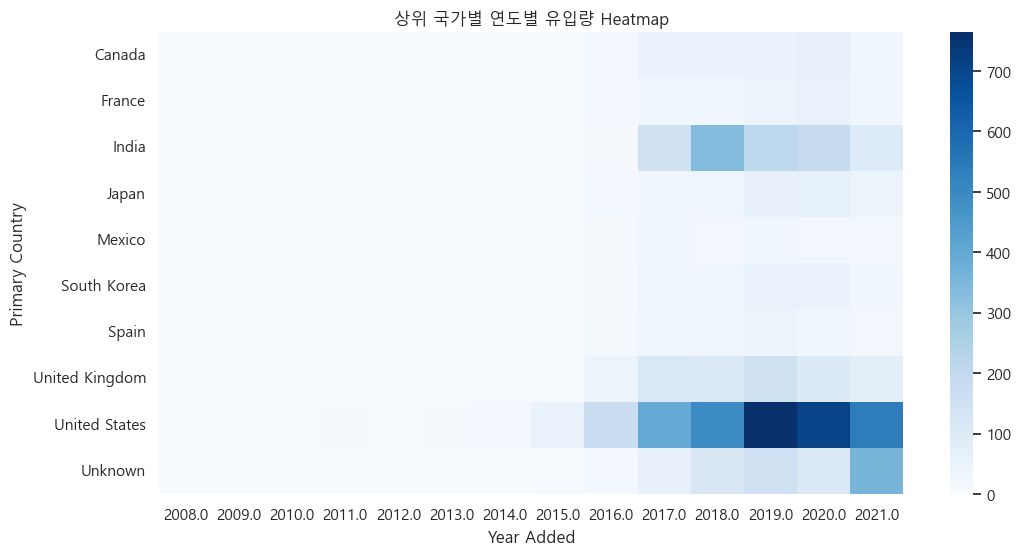

In [24]:
top_countries = df['primary_country'].value_counts().head(10).index

country_year = (
    df[df['primary_country'].isin(top_countries)]
      .dropna(subset=['year_added'])
      .groupby(['year_added', 'primary_country'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))
country_year.plot()
plt.title('상위 국가별 연도별 유입 콘텐츠 수')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(country_year.T, cmap='Blues')
plt.title('상위 국가별 연도별 유입량 Heatmap')
plt.xlabel('Year Added')
plt.ylabel('Primary Country')
plt.show()

### 해석
- 국가별 확장 속도는 동일하지 않았으며, 미국과 인도는 절대량이 크고 일본·한국은 상대적으로 **TV Show 비중이 높은 국가**로 나타났다.
- Movie/TV Show 구성비를 보면 **India는 Movie 92.0%**, **South Korea는 TV Show 77.7%**, **Japan는 TV Show 67.2%**로 국가별 차이가 뚜렷했다.
- 대표 장르 역시 국가마다 달랐는데, **Japan는 Anime Series**, **United Kingdom는 British TV Shows**, **South Korea는 International TV Shows**가 상위에 나타났다.
- 즉, 이 데이터는 단순 국가 순위보다 **“국가별 콘텐츠 포지션 차이”**를 보는 방향이 더 적절하다고 판단했다.

## 7. 가설 4 — Netflix는 신작 위주로 들여오는가, 아니면 구작 라이브러리도 많이 확보하는가?

### 확인사항
- 작품 공개 후 Netflix에 올라오기까지 걸린 시간을 대략 계산했을 때, Movie와 TV Show의 패턴이 다른지

### 목적
- 단순 개수 비교를 넘어서, **넷플릭스가 콘텐츠를 어떤 방식으로 확보해 왔는지**를 간접적으로 살펴본다.

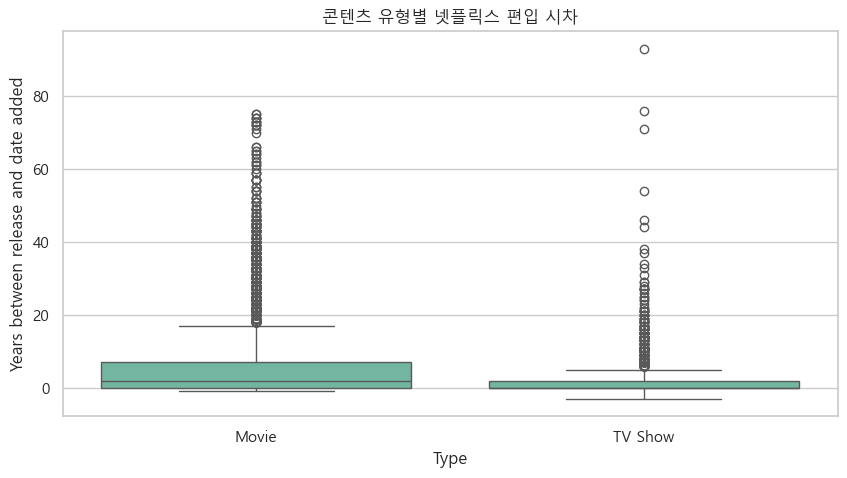

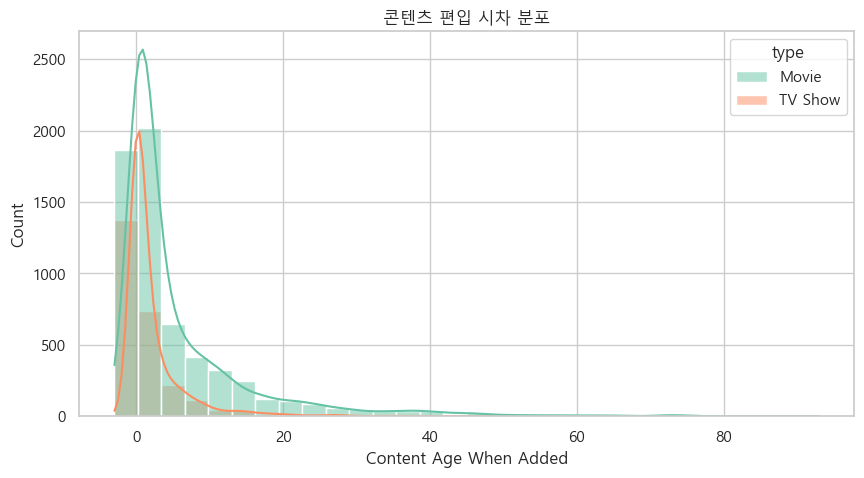

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,6131.0,5.73,9.74,-1.0,0.0,2.0,7.0,75.0
TV Show,2578.0,2.22,5.18,-3.0,0.0,0.0,2.0,93.0


In [25]:
lag_df = df.dropna(subset=['content_age_when_added']).copy()

plt.figure(figsize=(10, 5))
sns.boxplot(data=lag_df, x='type', y='content_age_when_added')
plt.title('콘텐츠 유형별 넷플릭스 편입 시차')
plt.xlabel('Type')
plt.ylabel('Years between release and date added')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=lag_df, x='content_age_when_added', hue='type', bins=30, kde=True)
plt.title('콘텐츠 편입 시차 분포')
plt.xlabel('Content Age When Added')
plt.ylabel('Count')
plt.show()

lag_summary = lag_df.groupby('type')['content_age_when_added'].describe().round(2)
display(lag_summary)


### 해석
- 중앙값 기준으로 보면 **Movie는 2년**, **TV Show는 0년**으로 나타났다.
- 즉, TV Show는 상대적으로 **공개 직후 빠르게 편입되는 경우가 많고**, Movie는 신작과 구작이 더 넓게 섞여 있는 구조로 보인다.
- 평균 역시 **Movie 5.73년 / TV Show 2.22년**으로 차이를 보였다.
- 다만 일부 음수값과 극단값이 존재하므로, 이 지표는 어디까지나 **편입 속도를 보는 간접 참고 지표**로 해석하는 것이 안전하다.

## 8. 모델링 후보로 바로 가도 되는가?

### 확인사항
- `rating` 원본 클래스를 그대로 쓰기 적절한지, 그룹화한 `rating_group`이 더 현실적인지
- 텍스트 컬럼 품질은 어느 정도인지

### 목적
- 모델링을 바로 진행하기보다, **현재 데이터 상태에서 시도할 가치가 있는지 먼저 판단**한다.

rating 원본 분포


,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


rating_group 분포


,count
rating_group,
Adults,4009
Teens,3800
Kids,902
Not Rated / Unknown,90
Other,6


텍스트 관련 컬럼 결측 비율(%)
title          0.0
description    0.0
cast           0.0
director       0.0
listed_in      0.0
dtype: float64


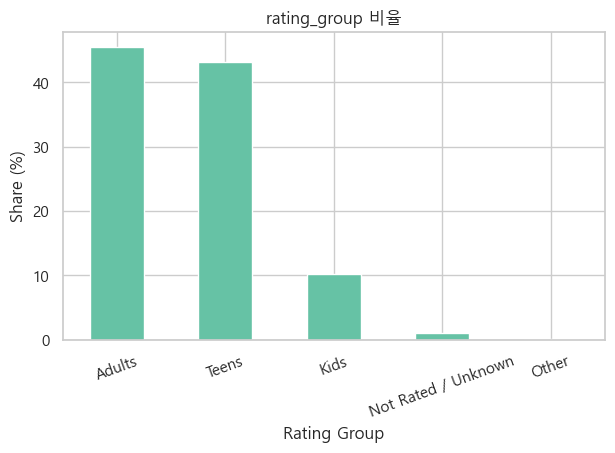

In [11]:
print("rating 원본 분포")
display(df["rating"].value_counts(dropna=False).to_frame("count"))

print("rating_group 분포")
display(df["rating_group"].value_counts(dropna=False).to_frame("count"))

text_cols = ["title", "description", "cast", "director", "listed_in"]
text_missing = (df[text_cols].isna().mean() * 100).round(2)
print("텍스트 관련 컬럼 결측 비율(%)")
print(text_missing)

plt.figure(figsize=(7, 4))
(df["rating_group"].value_counts(normalize=True) * 100).plot(kind="bar")
plt.title("rating_group 비율")
plt.xlabel("Rating Group")
plt.ylabel("Share (%)")
plt.xticks(rotation=20)
plt.show()

### 해석
- 원본 `rating`은 **TV-MA, TV-14, TV-PG**에 많이 몰려 있고, `NC-17`, `UR` 같은 희소 클래스도 존재한다.
- 반면 `rating_group`으로 묶으면 **Adults 45.52%, Teens 43.15%, Kids 10.24%** 수준으로 정리되어, 해석과 모델링 모두 더 단순해진다.
- 텍스트 컬럼 중 `title`, `description`, `listed_in`은 결측이 거의 없지만, `cast`, `director`는 결측이 많아 바로 활용하기에는 부담이 있다.
- 따라서 모델링을 진행한다면, **원본 `rating` 다중분류보다 `title + description + listed_in` 중심의 `rating_group` 분류**가 더 현실적이라고 판단했다.

## 9. 이번 EDA를 통해 우선 확정한 분석 범위

### 메인 주제로 적합한 방향
1. **넷플릭스 카탈로그 포트폴리오 변화 분석**  
   - Movie / TV Show 중심 구조와 시간에 따른 변화 확인
   - 연도별 유입량, Movie/TV Show 비중 변화, 주요 국가 확대 시점 확인

2. **주요 국가별 콘텐츠 포지션 차이 분석**  
   - 미국/인도/일본/한국 등 주요 국가별 역할 차이 설명
   - 국가별 유형·장르·등급 구성비 차이를 통해 현지화 전략을 간접 해석 가능

3. **콘텐츠 편입 시차 분석**  
   - 공개 후 넷플릭스 편입까지의 시차를 통해 신작 중심 vs 라이브러리 보강 패턴 확인 가능
   - 신작 중심 편입인지, 구작 라이브러리 보강인지 간접 해석

### 보조 주제로 검토할 수 있는 것
- `rating_group` 분류 모델링
- `type` 분류 또는 간단한 장르 예측

### 지금 단계에서 메인으로 두기 어려운 것
- 인기 콘텐츠 분석
- 개인화 추천시스템
- 최신 넷플릭스 전략에 대한 단정적 해석

## 10. 최종 한계점 정리

- 이 데이터는 **사용자 행동 데이터가 아니라 카탈로그 메타데이터**이므로, 시청 성과나 인기 여부를 직접 판단하기는 어렵다.
- `country`, `listed_in`은 다중값 컬럼이기 때문에, 이번 EDA에서는 **대표값 기준으로 단순화**해 사용했다. 따라서 해석은 직관적이지만 일부 정보 손실이 있을 수 있다.
- `date_added` 결측과 `rating` 품질 이슈가 있으므로, 전처리 기준을 함께 문서화해야 결과 해석의 신뢰도를 높일 수 있다.
- 이번 결과는 **설명적 EDA** 수준의 해석이며, 넷플릭스의 실제 전략을 인과적으로 증명하는 것은 아니다.